In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# DATA_PATH = Path("data/road_event_history_v1.parquet")
DATA_PATH = Path("data/road_event_history_v2.parquet")

df = pd.read_parquet(DATA_PATH)

print(df.shape)
df.head()

(6637233, 47)


,Segment_ID,Lifecycle_ID,event_date,year,event_type,event_order,Event_Idx,Measurement_Idx,ptm_idx,tp_idx,...,Toim_lk,Pituus,ELY,Tie,Ajorata,Kaista,Aosa,Aet,Losa,Let
0,Epo_13_0_11_104_1800_104_1900,Epo_13_0_11_104_1800_104_1900_C0,2009-04-22,2009,PTM,1,1,1,11.0,NaN,...,valta,100,Epo,13,0,11,104,1800,104,1900
1,Epo_13_0_11_104_1800_104_1900,Epo_13_0_11_104_1800_104_1900_C0,2010-07-12,2010,TP,0,2,<NA>,NaN,3.0,...,valta,100,Epo,13,0,11,104,1800,104,1900
2,Epo_13_0_11_104_1800_104_1900,Epo_13_0_11_104_1800_104_1900_C1,2012-07-16,2012,PTM,1,3,1,10.0,NaN,...,valta,100,Epo,13,0,11,104,1800,104,1900
3,Epo_13_0_11_104_1800_104_1900,Epo_13_0_11_104_1800_104_1900_C1,2013-06-26,2013,PTM,1,4,2,9.0,NaN,...,valta,100,Epo,13,0,11,104,1800,104,1900
4,Epo_13_0_11_104_1800_104_1900,Epo_13_0_11_104_1800_104_1900_C1,2014-04-16,2014,PTM,1,5,3,8.0,NaN,...,valta,100,Epo,13,0,11,104,1800,104,1900


### Basic schema and quick overview

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
for c in df.columns:
    print(" -", c)

print("\nDtypes:")
print(df.dtypes.sort_index())

print("\nMemory usage (MB):", round(df.memory_usage(deep=True).sum() / 1024**2, 2))

print("\nHead:")
display(df.head())

print("\nTail:")
display(df.tail())

Shape: (6637233, 47)

Columns:
 - Segment_ID
 - Lifecycle_ID
 - event_date
 - year
 - event_type
 - event_order
 - Event_Idx
 - Measurement_Idx
 - ptm_idx
 - tp_idx
 - IRI
 - URA
 - prev_IRI
 - prev_URA
 - delta_IRI
 - delta_URA
 - prev_meas_date
 - next_meas_date
 - Delta_t_days
 - Delta_t_years
 - days_since_prev_meas
 - days_until_next_meas
 - Pavement_Age_years
 - Initial_URA
 - tp_count_interval
 - has_TP_interval
 - is_minor_treatment
 - Minor_TP_Count
 - is_major_reset
 - is_phantom_reset
 - cycle_num
 - Tp_pinta
 - Tp_tyomen
 - KVL
 - KVL_raskas
 - KVL_kaista
 - Nopeus
 - Toim_lk
 - Pituus
 - ELY
 - Tie
 - Ajorata
 - Kaista
 - Aosa
 - Aet
 - Losa
 - Let

Dtypes:
Aet                              int64
Ajorata                          int64
Aosa                             int64
Delta_t_days                   float64
Delta_t_years                  float64
ELY                             object
Event_Idx                        int64
IRI                            float64
Initial_U

,Segment_ID,Lifecycle_ID,event_date,year,event_type,event_order,Event_Idx,Measurement_Idx,ptm_idx,tp_idx,...,Toim_lk,Pituus,ELY,Tie,Ajorata,Kaista,Aosa,Aet,Losa,Let
0,Epo_13_0_11_104_1800_104_1900,Epo_13_0_11_104_1800_104_1900_C0,2009-04-22,2009,PTM,1,1,1,11.0,NaN,...,valta,100,Epo,13,0,11,104,1800,104,1900
1,Epo_13_0_11_104_1800_104_1900,Epo_13_0_11_104_1800_104_1900_C0,2010-07-12,2010,TP,0,2,<NA>,NaN,3.0,...,valta,100,Epo,13,0,11,104,1800,104,1900
2,Epo_13_0_11_104_1800_104_1900,Epo_13_0_11_104_1800_104_1900_C1,2012-07-16,2012,PTM,1,3,1,10.0,NaN,...,valta,100,Epo,13,0,11,104,1800,104,1900
3,Epo_13_0_11_104_1800_104_1900,Epo_13_0_11_104_1800_104_1900_C1,2013-06-26,2013,PTM,1,4,2,9.0,NaN,...,valta,100,Epo,13,0,11,104,1800,104,1900
4,Epo_13_0_11_104_1800_104_1900,Epo_13_0_11_104_1800_104_1900_C1,2014-04-16,2014,PTM,1,5,3,8.0,NaN,...,valta,100,Epo,13,0,11,104,1800,104,1900



Tail:


,Segment_ID,Lifecycle_ID,event_date,year,event_type,event_order,Event_Idx,Measurement_Idx,ptm_idx,tp_idx,...,Toim_lk,Pituus,ELY,Tie,Ajorata,Kaista,Aosa,Aet,Losa,Let
6637228,Var_9_2_21_103_700_103_800,Var_9_2_21_103_700_103_800_C2,2020-04-30,2020,PTM,1,11,3,4.0,NaN,...,valta,100,Var,9,2,21,103,700,103,800
6637229,Var_9_2_21_103_700_103_800,Var_9_2_21_103_700_103_800_C2,2021-04-22,2021,PTM,1,12,4,3.0,NaN,...,valta,100,Var,9,2,21,103,700,103,800
6637230,Var_9_2_21_103_700_103_800,Var_9_2_21_103_700_103_800_C2,2022-04-24,2022,PTM,1,13,5,2.0,NaN,...,valta,100,Var,9,2,21,103,700,103,800
6637231,Var_9_2_21_103_700_103_800,Var_9_2_21_103_700_103_800_C2,2023-04-06,2023,PTM,1,14,6,1.0,NaN,...,valta,100,Var,9,2,21,103,700,103,800
6637232,Var_9_2_21_103_700_103_800,Var_9_2_21_103_700_103_800_C2,2024-05-07,2024,TP,0,15,<NA>,NaN,1.0,...,valta,100,Var,9,2,21,103,700,103,800


### Normalize dtypes you likely want for inspection

In [4]:
date_cols = [
    "event_date",
    "prev_meas_date",
    "next_meas_date",
]

for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

nullable_int_cols = [
    "year",
    "Event_Idx",
    "Measurement_Idx",
    "ptm_idx",
    "tp_idx",
    "tp_count_interval",
    "Minor_TP_Count",
    "cycle_num",
]

for c in nullable_int_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")

print("Dtype normalization done.")

Dtype normalization done.


### Basic counts and event composition

In [5]:
print("Row count:", len(df))
print("Unique segments:", df["Segment_ID"].nunique() if "Segment_ID" in df.columns else "Segment_ID missing")
print("Unique lifecycles:", df["Lifecycle_ID"].nunique(dropna=True) if "Lifecycle_ID" in df.columns else "Lifecycle_ID missing")

if "event_type" in df.columns:
    print("\nEvent type counts:")
    display(df["event_type"].value_counts(dropna=False))

    print("\nEvent type proportions:")
    display(df["event_type"].value_counts(dropna=False, normalize=True).rename("proportion"))

if "year" in df.columns:
    print("\nYear range:", df["year"].min(), "->", df["year"].max())

Row count: 6637233
Unique segments: 1020374
Unique lifecycles: 1567997

Event type counts:


event_type
PTM    5401320
TP     1235913
Name: count, dtype: int64


Event type proportions:


event_type
PTM    0.813791
TP     0.186209
Name: proportion, dtype: float64


Year range: 2005 -> 2024


### Missing values summary

In [6]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "dtype": df.dtypes.astype(str),
})
missing = missing.sort_values(["missing_pct", "missing_count"], ascending=[False, False])

display(missing)

,missing_count,missing_pct,dtype
Tp_tyomen,5411121,81.526760,object
Tp_pinta,5406050,81.450357,object
tp_idx,5401320,81.379093,Int64
prev_IRI,2256287,33.994392,float64
prev_URA,2256287,33.994392,float64
delta_IRI,2256287,33.994392,float64
delta_URA,2256287,33.994392,float64
Delta_t_days,2256287,33.994392,float64
Delta_t_years,2256287,33.994392,float64
prev_meas_date,1624257,24.471900,datetime64[ns]


### Missing values by event type

In [7]:
if "event_type" not in df.columns:
    print("event_type column not found.")
else:
    out = []
    for ev_type, g in df.groupby("event_type", dropna=False):
        m = pd.DataFrame({
            "column": g.columns,
            "missing_count": g.isna().sum().values,
            "missing_pct": (g.isna().mean() * 100).values,
        })
        m["event_type"] = ev_type
        out.append(m)

    missing_by_type = pd.concat(out, ignore_index=True)
    missing_by_type = missing_by_type.sort_values(["event_type", "missing_pct"], ascending=[True, False])

    display(missing_by_type)

,column,missing_count,missing_pct,event_type
9,tp_idx,5401320,100.000000,PTM
31,Tp_pinta,5401320,100.000000,PTM
32,Tp_tyomen,5401320,100.000000,PTM
12,prev_IRI,1020374,18.891197,PTM
13,prev_URA,1020374,18.891197,PTM
...,...,...,...,...
89,Kaista,0,0.000000,TP
90,Aosa,0,0.000000,TP
91,Aet,0,0.000000,TP
92,Losa,0,0.000000,TP


### Numeric summary statistics

In [8]:
num_cols = df.select_dtypes(include=[np.number, "Float64", "Int64"]).columns.tolist()

print("Numeric columns:", num_cols)
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

Numeric columns: ['year', 'event_order', 'Event_Idx', 'Measurement_Idx', 'ptm_idx', 'tp_idx', 'IRI', 'URA', 'prev_IRI', 'prev_URA', 'delta_IRI', 'delta_URA', 'Delta_t_days', 'Delta_t_years', 'days_since_prev_meas', 'days_until_next_meas', 'Pavement_Age_years', 'Initial_URA', 'tp_count_interval', 'Minor_TP_Count', 'cycle_num', 'KVL', 'KVL_raskas', 'KVL_kaista', 'Nopeus', 'Pituus', 'Tie', 'Ajorata', 'Kaista', 'Aosa', 'Aet', 'Losa', 'Let']


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
year,6637233.0,2016.914898,5.128912,2005.0,2005.0,2008.0,2013.0,2018.0,2021.0,2024.0,2024.0,2024.0
event_order,6637233.0,0.813791,0.389275,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
Event_Idx,6637233.0,4.95647,3.659292,1.0,1.0,1.0,2.0,4.0,7.0,12.0,16.0,25.0
Measurement_Idx,5401320.0,2.867298,1.951729,1.0,1.0,1.0,1.0,2.0,4.0,7.0,9.0,15.0
ptm_idx,5401320.0,4.148627,2.965779,1.0,1.0,1.0,2.0,3.0,6.0,10.0,13.0,15.0
tp_idx,1235913.0,1.684779,1.009737,1.0,1.0,1.0,1.0,1.0,2.0,4.0,5.0,11.0
IRI,5401320.0,1.852437,1.059711,0.0,0.68,0.8,1.11,1.55,2.25,3.94,5.76,10.0
URA,5401320.0,7.919625,4.403456,0.0,1.6,2.4,4.6,7.1,10.5,16.1,21.1,40.0
prev_IRI,4380946.0,1.783271,0.986373,0.0,0.68,0.8,1.1,1.5,2.17,3.7,5.4,10.0
prev_URA,4380946.0,7.647559,4.251027,0.0,1.5,2.3,4.4,6.8,10.1,15.6,20.2,40.0


### Min/max audit for important columns

In [9]:
important_cols = [
    "IRI", "URA",
    "prev_IRI", "prev_URA",
    "delta_IRI", "delta_URA",
    "Delta_t_days", "Delta_t_years",
    "days_since_prev_meas", "days_until_next_meas",
    "Pavement_Age_years",
    "tp_count_interval",
    "Minor_TP_Count",
    "KVL", "KVL_raskas", "KVL_kaista",
    "Nopeus", "Pituus",
]

audit_rows = []
for c in important_cols:
    if c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce")
        audit_rows.append({
            "column": c,
            "non_null": s.notna().sum(),
            "min": s.min(),
            "max": s.max(),
            "mean": s.mean(),
            "median": s.median(),
            "n_negative": (s < 0).sum(),
            "n_zero": (s == 0).sum(),
        })

audit_df = pd.DataFrame(audit_rows).sort_values("column")
display(audit_df)

,column,non_null,min,max,mean,median,n_negative,n_zero
6,Delta_t_days,4380946,110.000000,6998.000000,800.795923,679.000000,0,0
7,Delta_t_years,4380946,0.301164,19.159480,2.192460,1.859001,0,0
0,IRI,5401320,0.000000,10.000000,1.852437,1.550000,0,45
13,KVL,6637233,1.000000,108372.000000,4839.402013,1321.000000,0,0
15,KVL_kaista,6637179,0.000000,27845.000000,1516.301678,556.000000,0,3564
14,KVL_raskas,6637233,0.000000,7380.000000,368.165369,110.000000,0,9455
12,Minor_TP_Count,5401320,0.000000,4.000000,0.350616,0.000000,0,3564861
16,Nopeus,6637233,20.000000,120.000000,80.661123,80.000000,0,0
10,Pavement_Age_years,6033350,0.000000,19.408624,3.609324,2.959617,0,1568283
17,Pituus,6637233,100.000000,100.000000,100.000000,100.000000,0,0


### Categorical summary

In [10]:
cat_candidates = [
    "event_type",
    "Tp_pinta",
    "Tp_tyomen",
    "Toim_lk",
    "is_major_reset",
    "is_phantom_reset",
    "is_minor_treatment",
    "has_TP_interval",
]

for c in cat_candidates:
    if c in df.columns:
        print(f"\n=== {c} ===")
        display(df[c].value_counts(dropna=False).head(30))

# # Non case-sensitive version
# for c in cat_candidates:
#     if c in df.columns:
#         print(f"\n=== {c} (case-insensitive) ===")
#         display(df[c].str.lower().value_counts(dropna=False).head(30))



=== event_type ===


event_type
PTM    5401320
TP     1235913
Name: count, dtype: int64


=== Tp_pinta ===


Tp_pinta
None         5406050
AB            650090
SMA           216487
PAB-V         153553
PAB-B         151866
sma            24941
ab             24393
Sora            2069
SIP             1774
ABK             1447
SOP             1279
ABS              726
pab-b            572
EA               416
pab-v            410
abk              288
sora             255
SORA             244
PAB-O            178
sop              104
abs               25
AA                20
ABTiivis          18
EI TIETOA         16
ei tietoa          8
sip                2
VA                 2
Name: count, dtype: int64


=== Tp_tyomen ===


...

is_phantom_reset
False    5323024
<NA>     1235913
True       78296
Name: count, dtype: Int64


=== is_minor_treatment ===


is_minor_treatment
False    4863683
<NA>     1235913
True      537637
Name: count, dtype: Int64


=== has_TP_interval ===


has_TP_interval
False    4394356
<NA>     1235913
True     1006964
Name: count, dtype: Int64

### Distribution plots for key numeric columns

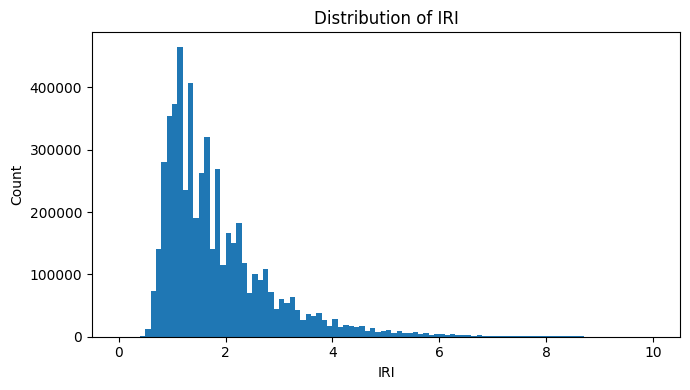

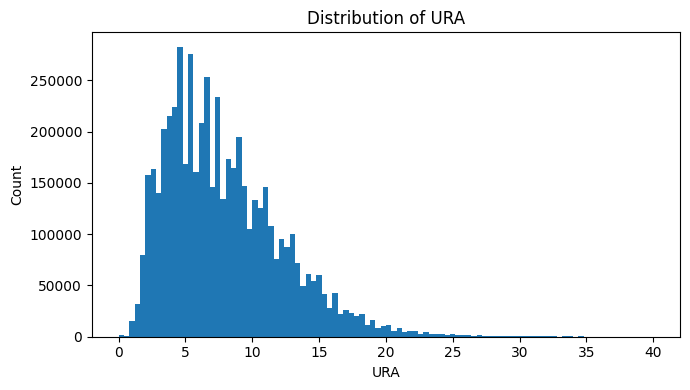

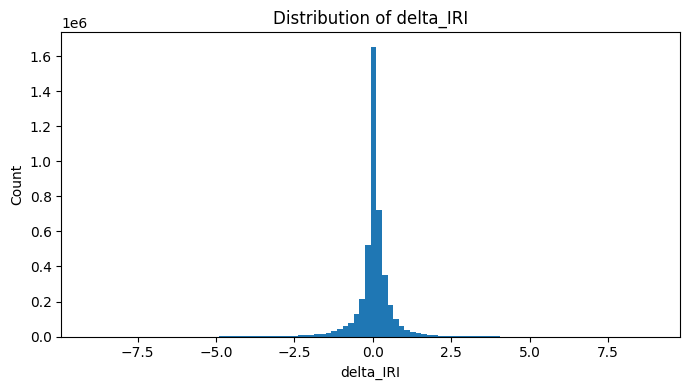

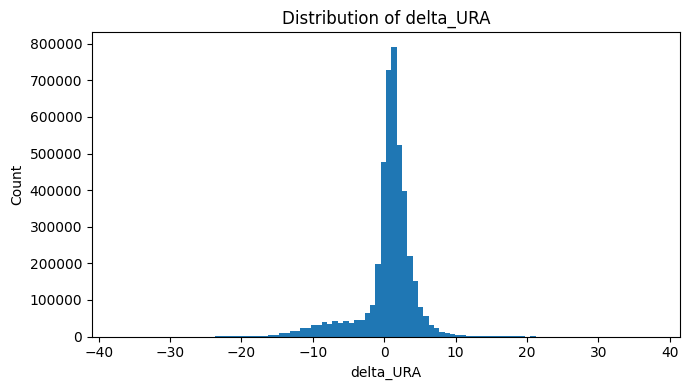

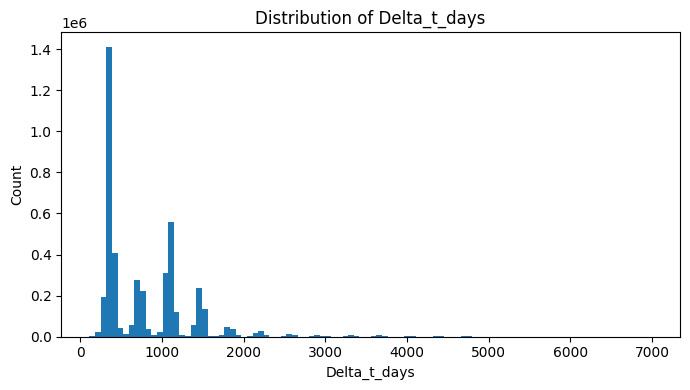

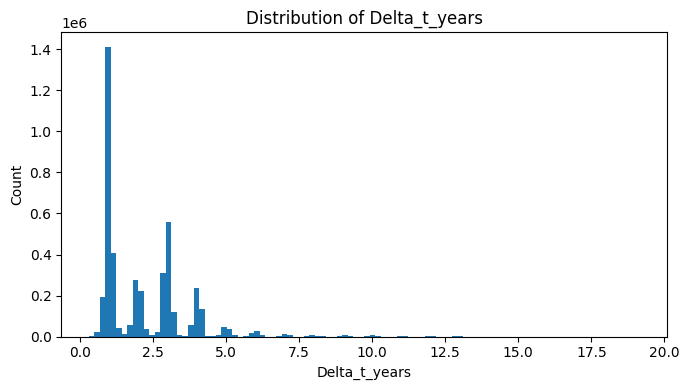

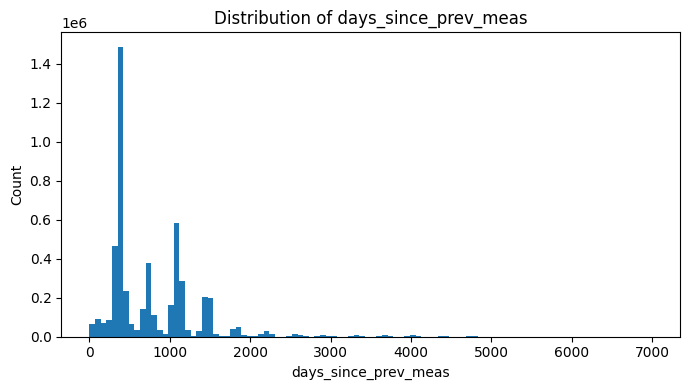

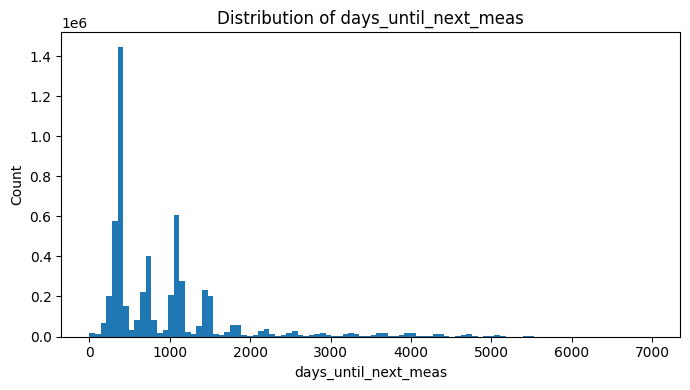

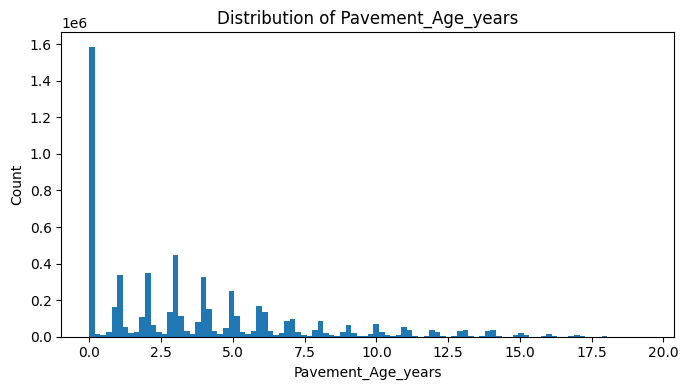

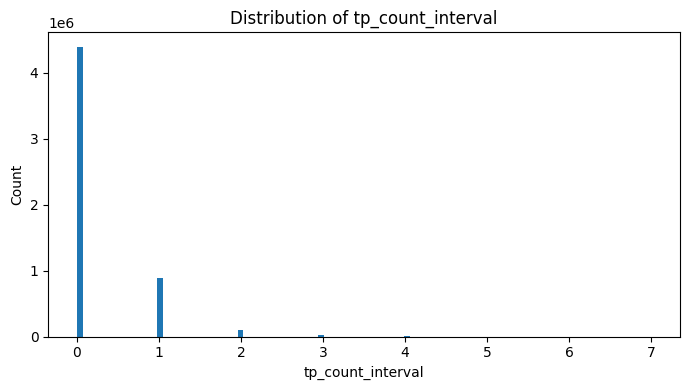

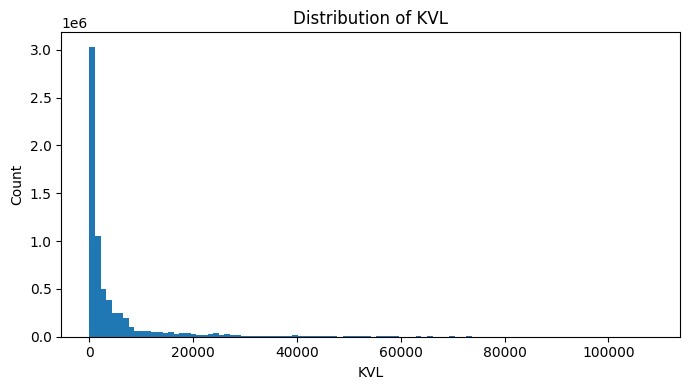

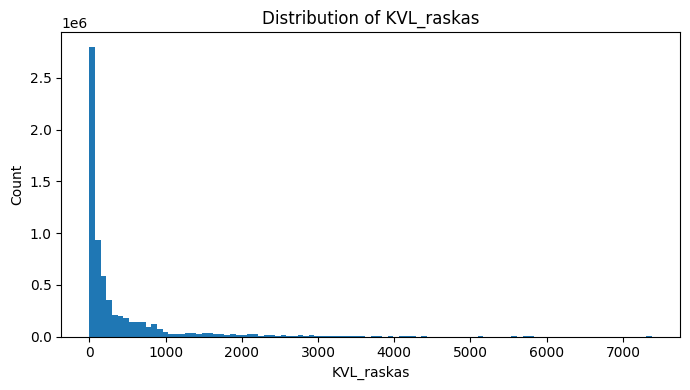

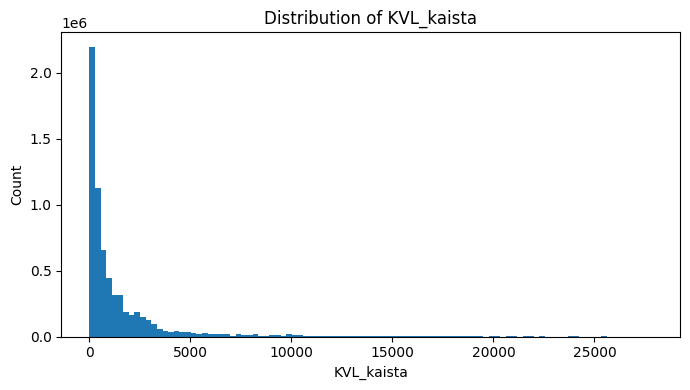

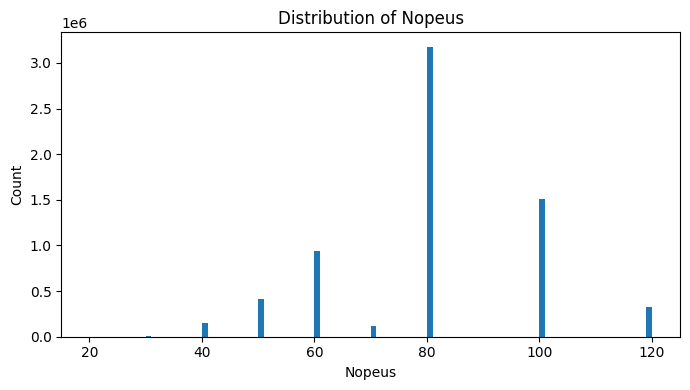

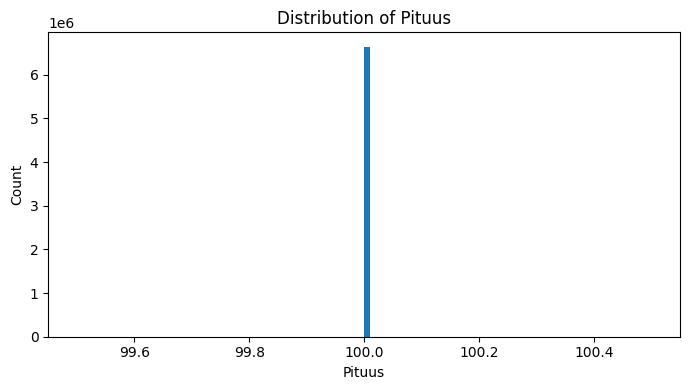

In [11]:
plot_cols = [
    "IRI", "URA",
    "delta_IRI", "delta_URA",
    "Delta_t_days", "Delta_t_years",
    "days_since_prev_meas", "days_until_next_meas",
    "Pavement_Age_years",
    "tp_count_interval",
    "KVL", "KVL_raskas", "KVL_kaista",
    "Nopeus", "Pituus",
]

for c in plot_cols:
    if c not in df.columns:
        continue

    s = pd.to_numeric(df[c], errors="coerce").dropna()
    if len(s) == 0:
        continue

    plt.figure(figsize=(7, 4))
    plt.hist(s, bins=100)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### PTM-only distributions

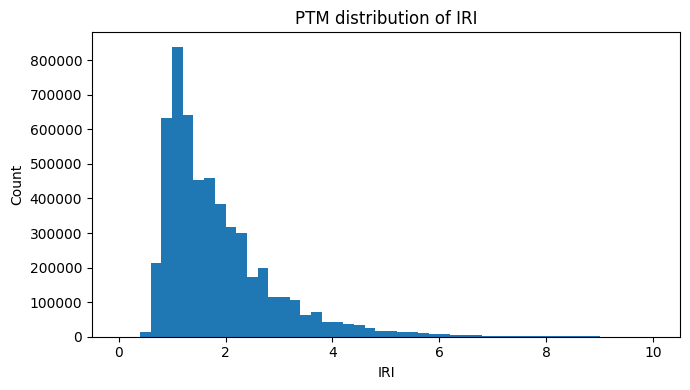

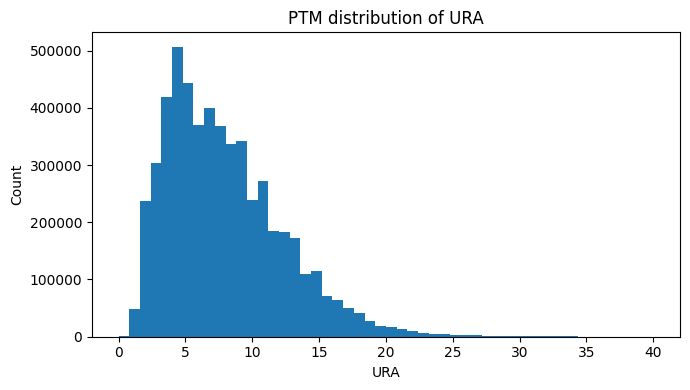

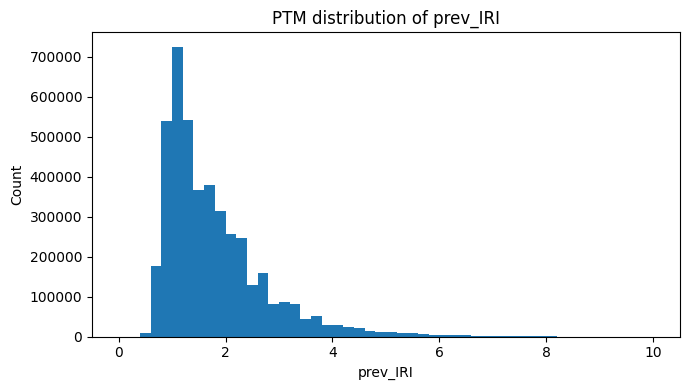

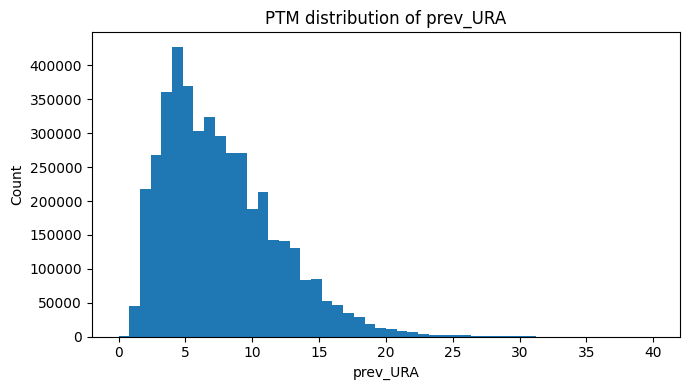

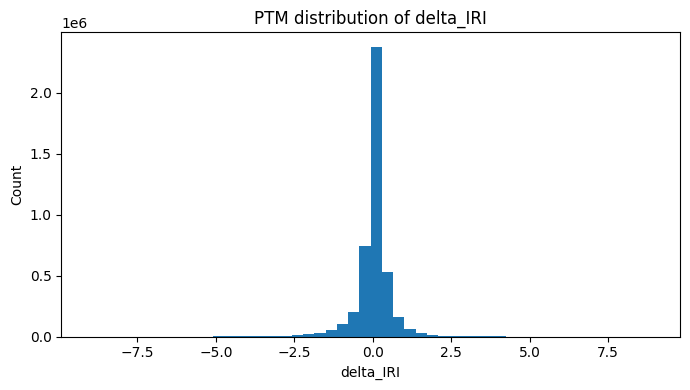

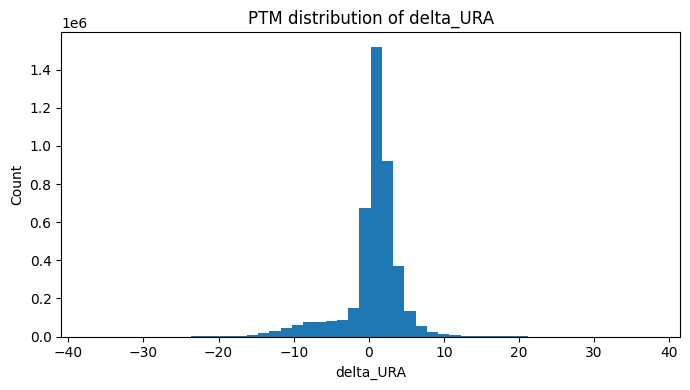

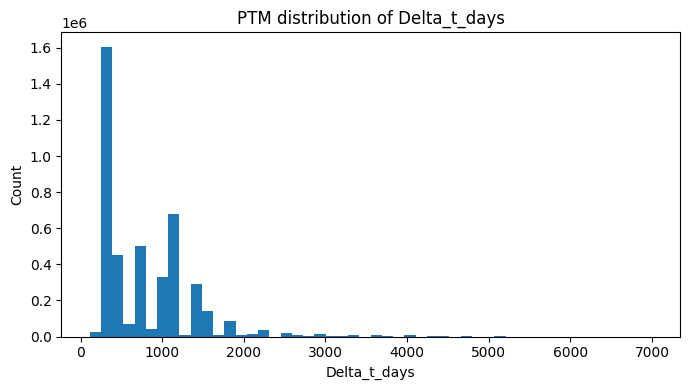

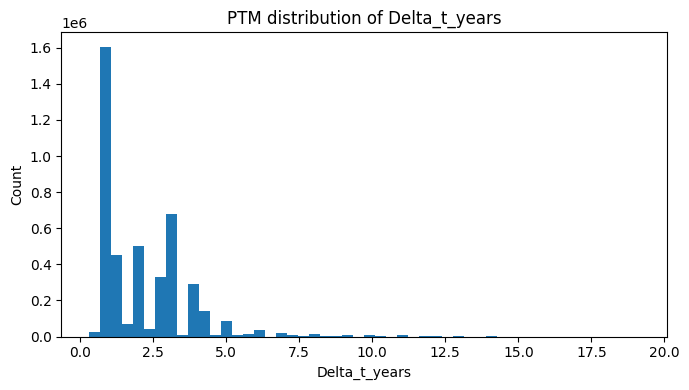

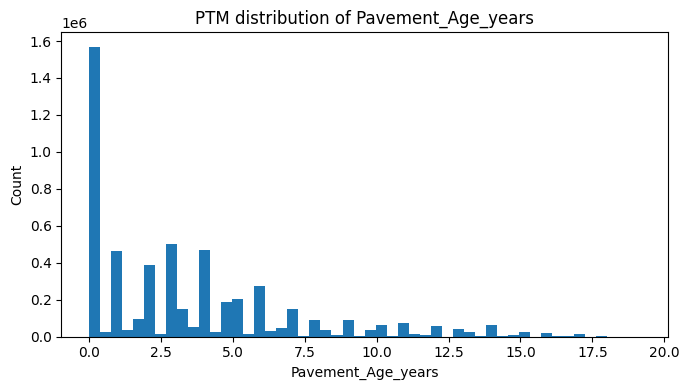

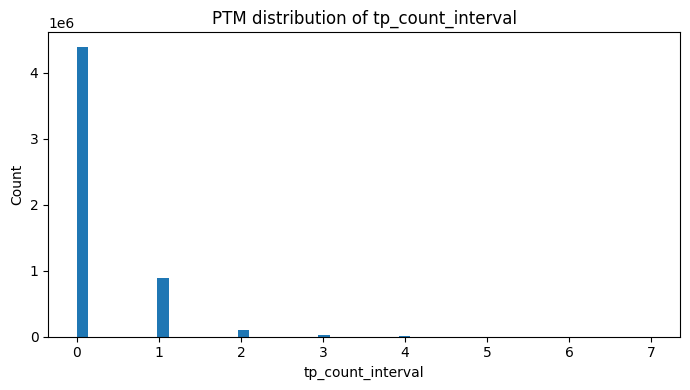

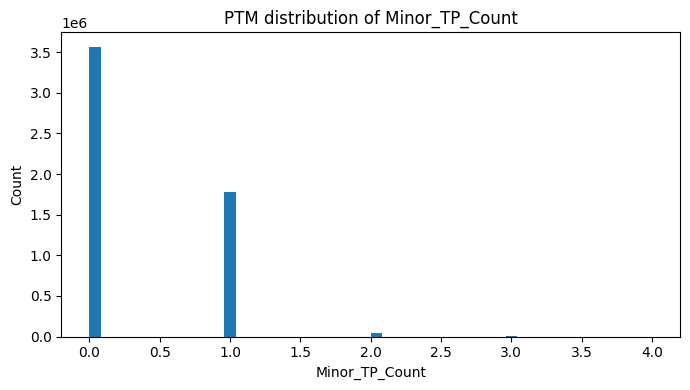

In [12]:
ptm = df[df["event_type"] == "PTM"].copy() if "event_type" in df.columns else df.copy()

ptm_plot_cols = [
    "IRI", "URA",
    "prev_IRI", "prev_URA",
    "delta_IRI", "delta_URA",
    "Delta_t_days", "Delta_t_years",
    "Pavement_Age_years",
    "tp_count_interval",
    "Minor_TP_Count",
]

for c in ptm_plot_cols:
    if c not in ptm.columns:
        continue

    s = pd.to_numeric(ptm[c], errors="coerce").dropna()
    if len(s) == 0:
        continue

    plt.figure(figsize=(7, 4))
    plt.hist(s, bins=50)
    plt.title(f"PTM distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Event counts per segment and per lifecycle

Events per segment:


count    1.020374e+06
mean     6.504706e+00
std      3.957887e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      9.000000e+00
max      2.500000e+01
dtype: float64

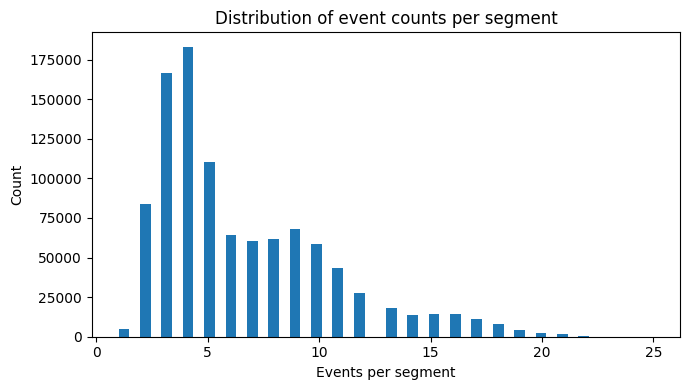

Events per lifecycle:


count    1.567997e+06
mean     3.847807e+00
std      2.233565e+00
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      5.000000e+00
max      1.700000e+01
dtype: float64

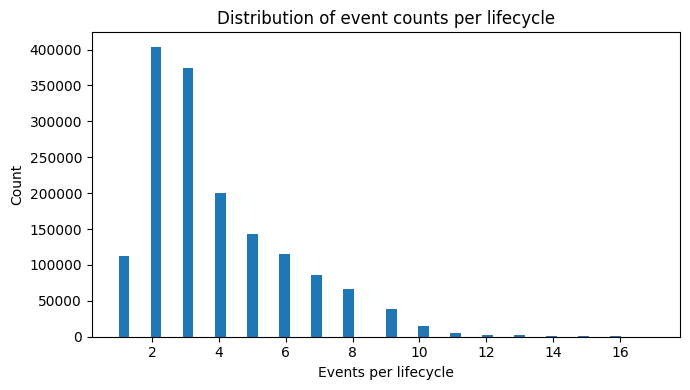

In [13]:
if "Segment_ID" in df.columns:
    seg_counts = df.groupby("Segment_ID").size().sort_values(ascending=False)
    print("Events per segment:")
    display(seg_counts.describe())

    plt.figure(figsize=(7, 4))
    plt.hist(seg_counts, bins=50)
    plt.title("Distribution of event counts per segment")
    plt.xlabel("Events per segment")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

if "Lifecycle_ID" in df.columns:
    lifecycle_counts = df.groupby("Lifecycle_ID").size().sort_values(ascending=False)
    print("Events per lifecycle:")
    display(lifecycle_counts.describe())

    plt.figure(figsize=(7, 4))
    plt.hist(lifecycle_counts, bins=50)
    plt.title("Distribution of event counts per lifecycle")
    plt.xlabel("Events per lifecycle")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Number of PTM and TP events per segment

,PTM,TP
Segment_ID,,
Epo_13309_0_11_3_6900_3_7000,2,1
Epo_13309_0_11_3_7000_3_7100,2,1
Epo_13309_0_11_3_7100_3_7200,2,1
Epo_13309_0_11_3_7200_3_7300,2,1
Epo_13309_0_11_3_7300_3_7400,2,1


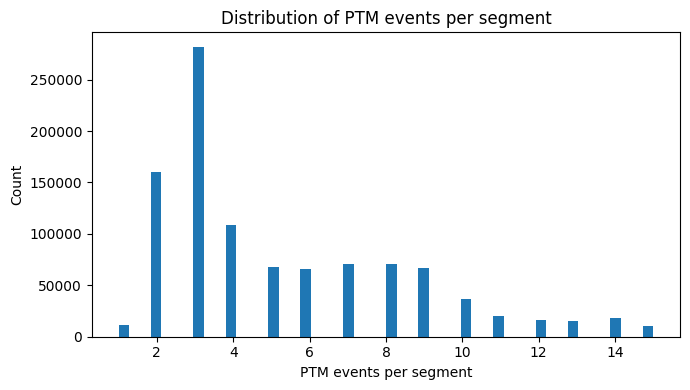

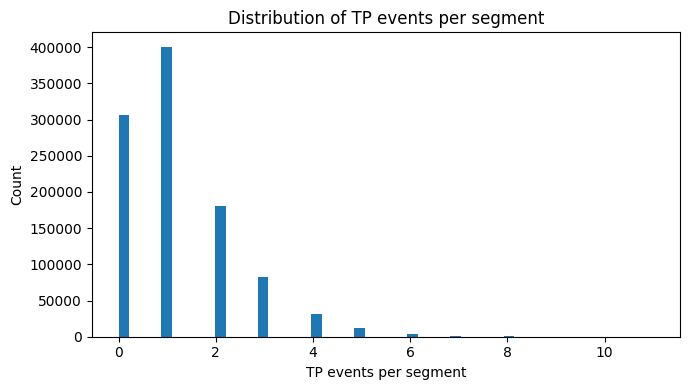

In [14]:
if {"Segment_ID", "event_type"}.issubset(df.columns):
    counts = (
        df.groupby(["Segment_ID", "event_type"])
          .size()
          .unstack(fill_value=0)
          .rename_axis(None, axis=1)
    )

    display(counts.head())

    for c in counts.columns:
        plt.figure(figsize=(7, 4))
        plt.hist(counts[c], bins=50)
        plt.title(f"Distribution of {c} events per segment")
        plt.xlabel(f"{c} events per segment")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

### Number of PTM events in a single lifecycle

PTM events per lifecycle:


count    1.567997e+06
mean     3.444726e+00
std      2.107902e+00
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      1.500000e+01
dtype: float64

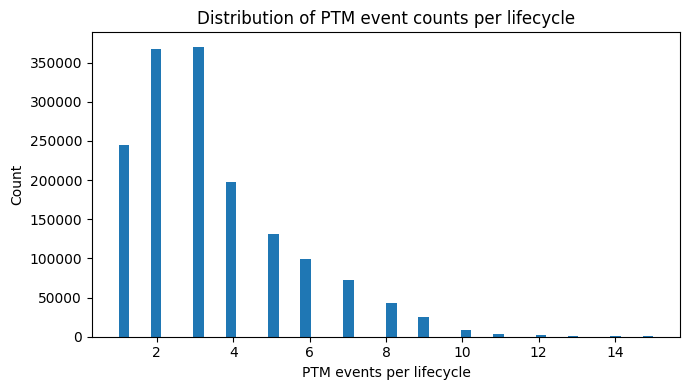

In [30]:
### Number of PTM events per lifecycle

if {"Lifecycle_ID", "event_type"}.issubset(df.columns):

    ptm_counts = (
        df[df["event_type"] == "PTM"]
        .groupby("Lifecycle_ID")
        .size()
        .sort_values(ascending=False)
    )

    print("PTM events per lifecycle:")
    display(ptm_counts.describe())

    plt.figure(figsize=(7, 4))
    plt.hist(ptm_counts, bins=50)
    plt.title("Distribution of PTM event counts per lifecycle")
    plt.xlabel("PTM events per lifecycle")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Date coverage plots

event_type,PTM,TP
year_plot,,
2005,3149,95218
2006,20778,82050
2007,40867,74402
2008,53173,66230
2009,76609,80336
2010,258198,66631
2011,250040,55665
2012,256596,43636
2013,265365,49099


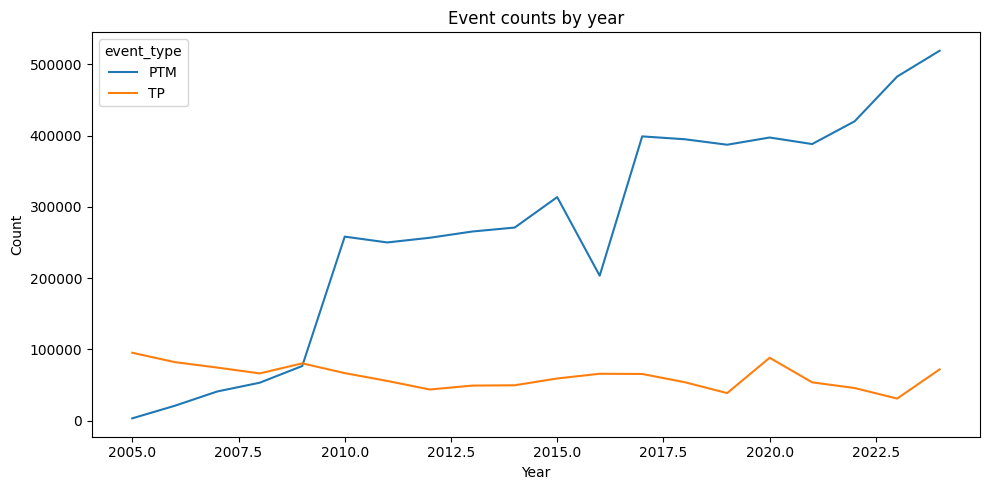

In [15]:
if "event_date" in df.columns:
    yearly = df.assign(year_plot=df["event_date"].dt.year).groupby(["year_plot", "event_type"]).size().unstack(fill_value=0)
    display(yearly.tail(20))

    yearly.plot(figsize=(10, 5))
    plt.title("Event counts by year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Correlation matrix for numeric columns

,IRI,URA,prev_IRI,prev_URA,delta_IRI,delta_URA,Delta_t_days,Delta_t_years,days_since_prev_meas,days_until_next_meas,Pavement_Age_years,tp_count_interval,Minor_TP_Count,cycle_num,KVL,KVL_raskas,KVL_kaista,Nopeus,Pituus
IRI,1.000000,0.234040,0.833441,0.088976,0.380147,0.186365,0.288966,0.288966,0.288966,0.285236,0.214317,-0.187618,-0.105222,-0.286378,-0.250154,-0.296476,-0.264424,-0.369069,NaN
URA,0.234040,1.000000,0.113762,0.616817,0.244982,0.475954,-0.113315,-0.113315,-0.113315,-0.128637,0.223522,-0.225499,0.032538,-0.027043,0.095725,0.086825,0.155427,-0.014668,NaN
prev_IRI,0.833441,0.113762,1.000000,0.185360,-0.194291,-0.074561,0.285236,0.285236,0.285236,0.290698,0.169213,0.046868,-0.114797,-0.216450,-0.250140,-0.297162,-0.262131,-0.378691,NaN
prev_URA,0.088976,0.616817,0.185360,1.000000,-0.152302,-0.398659,-0.128637,-0.128637,-0.128637,-0.120728,-0.101288,0.316962,-0.092961,0.165558,0.120393,0.111759,0.185917,-0.002755,NaN
delta_IRI,0.380147,0.244982,-0.194291,-0.152302,1.000000,0.455616,0.035536,0.035536,0.035536,0.056683,0.269446,-0.425947,0.090166,-0.191236,-0.032940,-0.037982,-0.035507,-0.039589,NaN
delta_URA,0.186365,0.475954,-0.074561,-0.398659,0.455616,1.000000,0.011703,0.011703,0.011703,0.014560,0.350907,-0.678511,0.191670,-0.272888,-0.042722,-0.046006,-0.044596,-0.035062,NaN
Delta_t_days,0.288966,-0.113315,0.285236,-0.128637,0.035536,0.011703,1.000000,1.000000,1.000000,0.495582,0.333377,0.149738,-0.004156,-0.171286,-0.299726,-0.326888,-0.304380,-0.210171,NaN
Delta_t_years,0.288966,-0.113315,0.285236,-0.128637,0.035536,0.011703,1.000000,1.000000,1.000000,0.495582,0.333377,0.149738,-0.004156,-0.171286,-0.299726,-0.326888,-0.304380,-0.210171,NaN
days_since_prev_meas,0.288966,-0.113315,0.285236,-0.128637,0.035536,0.011703,1.000000,1.000000,1.000000,0.445873,0.309874,0.149738,-0.004156,-0.152788,-0.299234,-0.326139,-0.306378,-0.211169,NaN
days_until_next_meas,0.285236,-0.128637,0.290698,-0.120728,0.056683,0.014560,0.495582,0.495582,0.445873,1.000000,-0.029410,0.008540,-0.024983,-0.234263,-0.230494,-0.248353,-0.226004,-0.150278,NaN


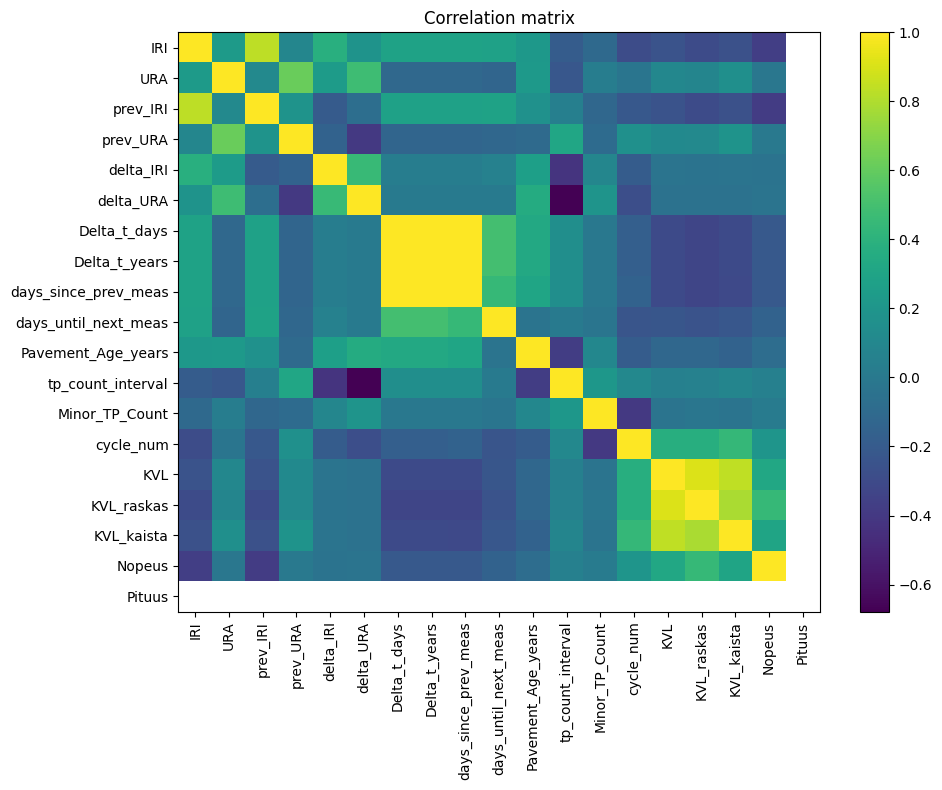

In [16]:
corr_cols = [
    "IRI", "URA",
    "prev_IRI", "prev_URA",
    "delta_IRI", "delta_URA",
    "Delta_t_days", "Delta_t_years",
    "days_since_prev_meas", "days_until_next_meas",
    "Pavement_Age_years",
    "tp_count_interval",
    "Minor_TP_Count",
    "cycle_num",
    "KVL", "KVL_raskas", "KVL_kaista",
    "Nopeus", "Pituus",
]

corr_cols = [c for c in corr_cols if c in df.columns]
corr_df = df[corr_cols].apply(pd.to_numeric, errors="coerce")

corr = corr_df.corr(numeric_only=True)
display(corr)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

### Correlation matrix for PTM rows only

,IRI,URA,prev_IRI,prev_URA,delta_IRI,delta_URA,Delta_t_days,Delta_t_years,days_since_prev_meas,days_until_next_meas,Pavement_Age_years,tp_count_interval,Minor_TP_Count,cycle_num,KVL,KVL_raskas,KVL_kaista,Nopeus,Pituus
IRI,1.000000,0.234040,0.833441,0.088976,0.380147,0.186365,0.288966,0.288966,0.288966,0.285236,0.214317,-0.187618,-0.105222,-0.286378,-0.250154,-0.296476,-0.264424,-0.369069,NaN
URA,0.234040,1.000000,0.113762,0.616817,0.244982,0.475954,-0.113315,-0.113315,-0.113315,-0.128637,0.223522,-0.225499,0.032538,-0.027043,0.095725,0.086825,0.155427,-0.014668,NaN
prev_IRI,0.833441,0.113762,1.000000,0.185360,-0.194291,-0.074561,0.285236,0.285236,0.285236,0.290698,0.169213,0.046868,-0.114797,-0.216450,-0.250140,-0.297162,-0.262131,-0.378691,NaN
prev_URA,0.088976,0.616817,0.185360,1.000000,-0.152302,-0.398659,-0.128637,-0.128637,-0.128637,-0.120728,-0.101288,0.316962,-0.092961,0.165558,0.120393,0.111759,0.185917,-0.002755,NaN
delta_IRI,0.380147,0.244982,-0.194291,-0.152302,1.000000,0.455616,0.035536,0.035536,0.035536,0.056683,0.269446,-0.425947,0.090166,-0.191236,-0.032940,-0.037982,-0.035507,-0.039589,NaN
delta_URA,0.186365,0.475954,-0.074561,-0.398659,0.455616,1.000000,0.011703,0.011703,0.011703,0.014560,0.350907,-0.678511,0.191670,-0.272888,-0.042722,-0.046006,-0.044596,-0.035062,NaN
Delta_t_days,0.288966,-0.113315,0.285236,-0.128637,0.035536,0.011703,1.000000,1.000000,1.000000,0.495582,0.333377,0.149738,-0.004156,-0.171286,-0.299726,-0.326888,-0.304380,-0.210171,NaN
Delta_t_years,0.288966,-0.113315,0.285236,-0.128637,0.035536,0.011703,1.000000,1.000000,1.000000,0.495582,0.333377,0.149738,-0.004156,-0.171286,-0.299726,-0.326888,-0.304380,-0.210171,NaN
days_since_prev_meas,0.288966,-0.113315,0.285236,-0.128637,0.035536,0.011703,1.000000,1.000000,1.000000,0.495582,0.333377,0.149738,-0.004156,-0.171286,-0.299726,-0.326888,-0.304380,-0.210171,NaN
days_until_next_meas,0.285236,-0.128637,0.290698,-0.120728,0.056683,0.014560,0.495582,0.495582,0.495582,1.000000,0.013079,0.008540,-0.024983,-0.244095,-0.299726,-0.326888,-0.304380,-0.210171,NaN


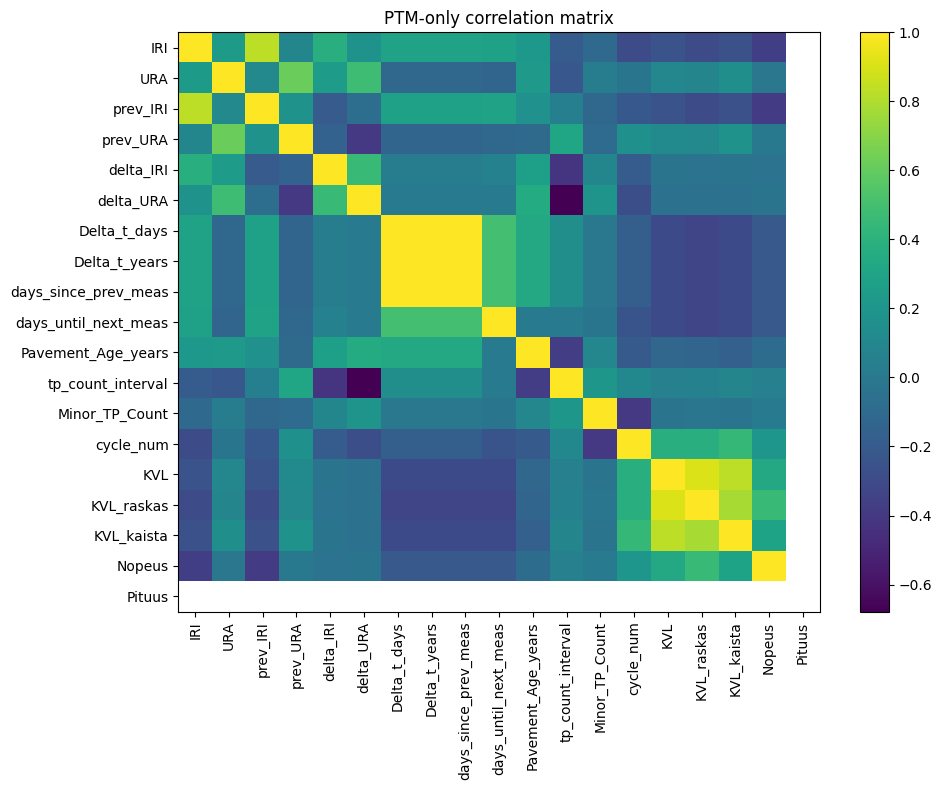

In [17]:
ptm_corr_cols = [c for c in corr_cols if c in ptm.columns]
ptm_corr_df = ptm[ptm_corr_cols].apply(pd.to_numeric, errors="coerce")
ptm_corr = ptm_corr_df.corr(numeric_only=True)

display(ptm_corr)

plt.figure(figsize=(10, 8))
plt.imshow(ptm_corr, aspect="auto")
plt.xticks(range(len(ptm_corr.columns)), ptm_corr.columns, rotation=90)
plt.yticks(range(len(ptm_corr.index)), ptm_corr.index)
plt.colorbar()
plt.title("PTM-only correlation matrix")
plt.tight_layout()
plt.show()

### Boolean flag summaries

In [18]:
bool_like_cols = [
    "has_TP_interval",
    "is_minor_treatment",
    "is_major_reset",
    "is_phantom_reset",
]

for c in bool_like_cols:
    if c in df.columns:
        print(f"\n=== {c} ===")
        display(df[c].value_counts(dropna=False))

        if "event_type" in df.columns:
            cross = pd.crosstab(df["event_type"], df[c], dropna=False)
            print("By event_type:")
            display(cross)


=== has_TP_interval ===


has_TP_interval
False    4394356
<NA>     1235913
True     1006964
Name: count, dtype: Int64

By event_type:


has_TP_interval,False,True,<NA>
event_type,,,
PTM,4394356,1006964,0
TP,0,0,1235913



=== is_minor_treatment ===


...

is_major_reset,False,True,<NA>
event_type,,,
PTM,4853697,547623,0
TP,0,0,1235913



=== is_phantom_reset ===


is_phantom_reset
False    5323024
<NA>     1235913
True       78296
Name: count, dtype: Int64

By event_type:


is_phantom_reset,False,True,<NA>
event_type,,,
PTM,5323024,78296,0
TP,0,0,1235913


### Useful integrity checks

In [19]:
checks = {}

if "Segment_ID" in df.columns:
    checks["missing Segment_ID"] = df["Segment_ID"].isna().sum()

if "event_type" in df.columns:
    checks["invalid event_type"] = (~df["event_type"].isin(["PTM", "TP"])).sum()

if "event_order" in df.columns:
    checks["invalid event_order"] = (~df["event_order"].isin([0, 1])).sum()

if {"event_type", "ptm_idx"}.issubset(df.columns):
    checks["PTM rows missing ptm_idx"] = ((df["event_type"] == "PTM") & (df["ptm_idx"].isna())).sum()

if {"event_type", "tp_idx"}.issubset(df.columns):
    checks["TP rows missing tp_idx"] = ((df["event_type"] == "TP") & (df["tp_idx"].isna())).sum()

if {"event_type", "URA"}.issubset(df.columns):
    checks["PTM rows missing URA"] = ((df["event_type"] == "PTM") & (df["URA"].isna())).sum()

if {"event_type", "IRI"}.issubset(df.columns):
    checks["PTM rows missing IRI"] = ((df["event_type"] == "PTM") & (df["IRI"].isna())).sum()

if {"event_type", "Tp_pinta"}.issubset(df.columns):
    checks["TP rows missing Tp_pinta"] = ((df["event_type"] == "TP") & (df["Tp_pinta"].isna())).sum()

if {"event_type", "Tp_tyomen"}.issubset(df.columns):
    checks["TP rows missing Tp_tyomen"] = ((df["event_type"] == "TP") & (df["Tp_tyomen"].isna())).sum()

pd.Series(checks, name="count")

missing Segment_ID              0
invalid event_type              0
invalid event_order             0
PTM rows missing ptm_idx        0
TP rows missing tp_idx          0
PTM rows missing URA            0
PTM rows missing IRI            0
TP rows missing Tp_pinta     4730
TP rows missing Tp_tyomen    9801
Name: count, dtype: int64

### Duplicate checks

In [20]:
dup_checks = {}

key1 = [c for c in ["Segment_ID", "event_date", "event_type", "ptm_idx"] if c in df.columns]
if set(["Segment_ID", "event_date", "event_type"]).issubset(df.columns) and "ptm_idx" in df.columns:
    dup_checks["duplicate PTM keys"] = (
        df[df["event_type"] == "PTM"]
        .duplicated(subset=key1, keep=False)
        .sum()
    )

key2 = [c for c in ["Segment_ID", "event_date", "event_type", "tp_idx", "Tp_pinta", "Tp_tyomen"] if c in df.columns]
if set(["Segment_ID", "event_date", "event_type"]).issubset(df.columns) and "tp_idx" in df.columns:
    dup_checks["duplicate TP keys"] = (
        df[df["event_type"] == "TP"]
        .duplicated(subset=key2, keep=False)
        .sum()
    )

pd.Series(dup_checks, name="count")

duplicate PTM keys    0
duplicate TP keys     0
Name: count, dtype: int64

### Out-of-range or suspicious values audit

In [21]:
suspicious = {}

def count_cond(col, cond):
    if col not in df.columns:
        return None
    s = pd.to_numeric(df[col], errors="coerce")
    return int(cond(s).sum())

checks = {
    "IRI < 0": ("IRI", lambda s: s < 0),
    "IRI > 20": ("IRI", lambda s: s > 20),
    "URA < 0": ("URA", lambda s: s < 0),
    "URA > 80": ("URA", lambda s: s > 80),
    "Delta_t_days < 0": ("Delta_t_days", lambda s: s < 0),
    "Pavement_Age_years < 0": ("Pavement_Age_years", lambda s: s < 0),
    "tp_count_interval < 0": ("tp_count_interval", lambda s: s < 0),
    "Minor_TP_Count < 0": ("Minor_TP_Count", lambda s: s < 0),
    "days_since_prev_meas < 0": ("days_since_prev_meas", lambda s: s < 0),
    "days_until_next_meas < 0": ("days_until_next_meas", lambda s: s < 0),
}

for name, (col, fn) in checks.items():
    val = count_cond(col, fn)
    if val is not None:
        suspicious[name] = val

pd.Series(suspicious, name="count")

IRI < 0                     0
IRI > 20                    0
URA < 0                     0
URA > 80                    0
Delta_t_days < 0            0
Pavement_Age_years < 0      0
tp_count_interval < 0       0
Minor_TP_Count < 0          0
days_since_prev_meas < 0    0
days_until_next_meas < 0    0
Name: count, dtype: int64

### Segment-level summary table

In [22]:
def build_segment_summary(df):
    g = df.groupby("Segment_ID", dropna=False)

    summary = pd.DataFrame({
        "n_events": g.size(),
        "n_ptm": g["event_type"].apply(lambda s: (s == "PTM").sum()) if "event_type" in df.columns else np.nan,
        "n_tp": g["event_type"].apply(lambda s: (s == "TP").sum()) if "event_type" in df.columns else np.nan,
        "start_date": g["event_date"].min() if "event_date" in df.columns else pd.NaT,
        "end_date": g["event_date"].max() if "event_date" in df.columns else pd.NaT,
    })

    if "Lifecycle_ID" in df.columns:
        summary["n_lifecycles"] = g["Lifecycle_ID"].nunique(dropna=True)

    if "URA" in df.columns:
        summary["URA_min"] = g["URA"].min()
        summary["URA_max"] = g["URA"].max()

    if "IRI" in df.columns:
        summary["IRI_min"] = g["IRI"].min()
        summary["IRI_max"] = g["IRI"].max()

    return summary.sort_values("n_events", ascending=False)

segment_summary = build_segment_summary(df)
display(segment_summary.head(20))

,n_events,n_ptm,n_tp,start_date,end_date,n_lifecycles,URA_min,URA_max,IRI_min,IRI_max
Segment_ID,,,,,,,,,,
Uud_3_2_21_116_2200_116_2300,25,14,11,2006-08-28,2024-09-18,6,4.5,14.8,1.21,1.64
Uud_3_2_21_116_3000_116_3100,25,14,11,2006-08-28,2024-09-18,7,5.5,16.2,1.05,1.54
Uud_45_2_21_2_5500_2_5600,24,15,9,2005-08-16,2024-04-11,7,6.1,20.6,0.76,1.27
Uud_45_2_21_2_5600_2_5700,24,15,9,2005-08-16,2024-04-11,7,7.0,27.1,0.82,1.39
Uud_45_2_21_2_6300_2_6400,24,15,9,2005-08-16,2024-04-11,7,5.8,22.3,1.11,2.25
Uud_45_2_21_2_5800_2_5900,24,15,9,2005-08-16,2024-04-11,7,5.6,23.5,0.81,1.40
Uud_45_2_21_2_5900_2_6000,24,15,9,2005-08-16,2024-04-11,7,5.6,25.0,0.90,1.40
Uud_45_2_21_2_5300_2_5400,24,15,9,2005-08-16,2024-04-11,7,4.8,19.6,0.81,1.73
Uud_3_1_11_103_4000_103_4100,24,15,9,2006-06-06,2024-05-07,5,4.3,20.4,1.00,1.88


### Lifecycle-level summary table

In [23]:
if "Lifecycle_ID" in df.columns:
    lifecycle_summary = (
        df[df["Lifecycle_ID"].notna()]
        .groupby("Lifecycle_ID")
        .agg(
            Segment_ID=("Segment_ID", "first"),
            n_events=("Lifecycle_ID", "size"),
            n_ptm=("event_type", lambda s: (s == "PTM").sum()),
            n_tp=("event_type", lambda s: (s == "TP").sum()),
            start_date=("event_date", "min"),
            end_date=("event_date", "max"),
            cycle_num=("cycle_num", "first") if "cycle_num" in df.columns else ("Lifecycle_ID", "size"),
        )
        .sort_values("n_events", ascending=False)
    )
    display(lifecycle_summary.head(20))

,Segment_ID,n_events,n_ptm,n_tp,start_date,end_date,cycle_num
Lifecycle_ID,,,,,,,
Kas_6_2_22_304_1900_304_2000_C0,Kas_6_2_22_304_1900_304_2000,17,14,3,2011-05-10,2024-06-16,0
Var_1_2_22_21_1500_21_1600_C0,Var_1_2_22_21_1500_21_1600,17,15,2,2010-04-14,2024-04-08,0
Uud_145_0_12_4_1000_4_1100_C0,Uud_145_0_12_4_1000_4_1100,17,15,2,2009-06-22,2024-09-10,0
Uud_7_2_22_12_700_12_800_C0,Uud_7_2_22_12_700_12_800,17,14,3,2010-04-12,2024-04-27,0
Var_1_2_22_21_3900_21_4000_C0,Var_1_2_22_21_3900_21_4000,17,15,2,2010-04-14,2024-04-08,0
Var_1_2_22_18_2600_18_2700_C0,Var_1_2_22_18_2600_18_2700,17,15,2,2010-04-14,2024-04-08,0
Var_1_2_22_21_3400_21_3500_C0,Var_1_2_22_21_3400_21_3500,17,15,2,2010-04-14,2024-04-08,0
Var_1_2_22_18_1800_18_1900_C0,Var_1_2_22_18_1800_18_1900,17,15,2,2010-04-14,2024-04-08,0
Var_1_2_22_18_1900_18_2000_C0,Var_1_2_22_18_1900_18_2000,17,15,2,2010-04-14,2024-04-08,0


### Print history of a given or random segment

In [24]:
def get_random_segment_id(df, min_events=1, min_ptm=1):
    if "Segment_ID" not in df.columns:
        raise ValueError("Segment_ID column not found.")

    work = df.copy()

    counts = work.groupby("Segment_ID").size().rename("n_events").to_frame()

    if "event_type" in work.columns:
        counts["n_ptm"] = work.groupby("Segment_ID")["event_type"].apply(lambda s: (s == "PTM").sum())
    else:
        counts["n_ptm"] = 0

    eligible = counts[(counts["n_events"] >= min_events) & (counts["n_ptm"] >= min_ptm)].index.tolist()

    if not eligible:
        raise ValueError("No eligible segments found with the given thresholds.")

    return random.choice(eligible)


def get_segment_history(df, segment_id):
    g = df[df["Segment_ID"] == segment_id].copy()
    if g.empty:
        raise ValueError(f"No rows found for Segment_ID={segment_id}")
    g = g.sort_values(["event_date", "event_order", "ptm_idx", "tp_idx"], kind="mergesort", na_position="last")
    return g.reset_index(drop=True)


# Set segment_id manually, or leave as None for random
segment_id = None

if segment_id is None:
    segment_id = get_random_segment_id(df, min_events=5, min_ptm=3)

seg = get_segment_history(df, segment_id)

print("Segment_ID:", segment_id)
print("Rows:", len(seg))
display(seg)

Segment_ID: Var_2053_0_11_2_4600_2_4700
Rows: 6


,Segment_ID,Lifecycle_ID,event_date,year,event_type,event_order,Event_Idx,Measurement_Idx,ptm_idx,tp_idx,...,Toim_lk,Pituus,ELY,Tie,Ajorata,Kaista,Aosa,Aet,Losa,Let
0,Var_2053_0_11_2_4600_2_4700,Var_2053_0_11_2_4600_2_4700_C0,2007-06-13,2007,PTM,1,1,1,6,<NA>,...,yhdys,100,Var,2053,0,11,2,4600,2,4700
1,Var_2053_0_11_2_4600_2_4700,Var_2053_0_11_2_4600_2_4700_C0,2012-05-03,2012,PTM,1,2,2,5,<NA>,...,yhdys,100,Var,2053,0,11,2,4600,2,4700
2,Var_2053_0_11_2_4600_2_4700,Var_2053_0_11_2_4600_2_4700_C0,2015-05-21,2015,PTM,1,3,3,4,<NA>,...,yhdys,100,Var,2053,0,11,2,4600,2,4700
3,Var_2053_0_11_2_4600_2_4700,Var_2053_0_11_2_4600_2_4700_C0,2018-06-12,2018,PTM,1,4,4,3,<NA>,...,yhdys,100,Var,2053,0,11,2,4600,2,4700
4,Var_2053_0_11_2_4600_2_4700,Var_2053_0_11_2_4600_2_4700_C0,2021-07-11,2021,PTM,1,5,5,2,<NA>,...,yhdys,100,Var,2053,0,11,2,4600,2,4700
5,Var_2053_0_11_2_4600_2_4700,Var_2053_0_11_2_4600_2_4700_C0,2024-05-11,2024,PTM,1,6,6,1,<NA>,...,yhdys,100,Var,2053,0,11,2,4600,2,4700


### Plot deterioration history and TP events for one segment

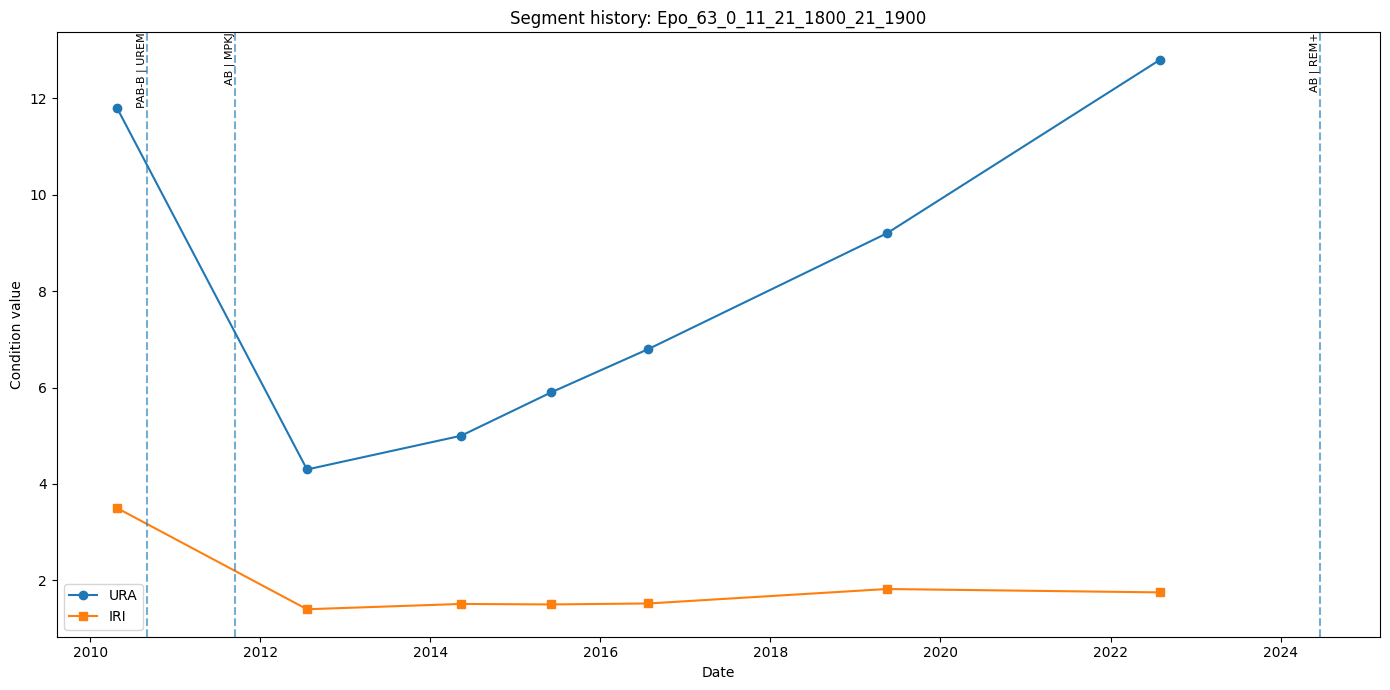

,Segment_ID,Lifecycle_ID,event_date,year,event_type,event_order,Event_Idx,Measurement_Idx,ptm_idx,tp_idx,...,Toim_lk,Pituus,ELY,Tie,Ajorata,Kaista,Aosa,Aet,Losa,Let
0,Epo_63_0_11_21_1800_21_1900,Epo_63_0_11_21_1800_21_1900_C0,2010-04-26,2010,PTM,1,1,1,7,<NA>,...,kanta,100,Epo,63,0,11,21,1800,21,1900
1,Epo_63_0_11_21_1800_21_1900,Epo_63_0_11_21_1800_21_1900_C0,2010-09-01,2010,TP,0,2,<NA>,<NA>,3,...,kanta,100,Epo,63,0,11,21,1800,21,1900
2,Epo_63_0_11_21_1800_21_1900,Epo_63_0_11_21_1800_21_1900_C0,2011-09-16,2011,TP,0,3,<NA>,<NA>,2,...,kanta,100,Epo,63,0,11,21,1800,21,1900
3,Epo_63_0_11_21_1800_21_1900,Epo_63_0_11_21_1800_21_1900_C1,2012-07-20,2012,PTM,1,4,1,6,<NA>,...,kanta,100,Epo,63,0,11,21,1800,21,1900
4,Epo_63_0_11_21_1800_21_1900,Epo_63_0_11_21_1800_21_1900_C1,2014-05-13,2014,PTM,1,5,2,5,<NA>,...,kanta,100,Epo,63,0,11,21,1800,21,1900
5,Epo_63_0_11_21_1800_21_1900,Epo_63_0_11_21_1800_21_1900_C1,2015-06-04,2015,PTM,1,6,3,4,<NA>,...,kanta,100,Epo,63,0,11,21,1800,21,1900
6,Epo_63_0_11_21_1800_21_1900,Epo_63_0_11_21_1800_21_1900_C1,2016-07-26,2016,PTM,1,7,4,3,<NA>,...,kanta,100,Epo,63,0,11,21,1800,21,1900
7,Epo_63_0_11_21_1800_21_1900,Epo_63_0_11_21_1800_21_1900_C1,2019-05-16,2019,PTM,1,8,5,2,<NA>,...,kanta,100,Epo,63,0,11,21,1800,21,1900
8,Epo_63_0_11_21_1800_21_1900,Epo_63_0_11_21_1800_21_1900_C1,2022-08-01,2022,PTM,1,9,6,1,<NA>,...,kanta,100,Epo,63,0,11,21,1800,21,1900
9,Epo_63_0_11_21_1800_21_1900,Epo_63_0_11_21_1800_21_1900_C1,2024-06-18,2024,TP,0,10,<NA>,<NA>,1,...,kanta,100,Epo,63,0,11,21,1800,21,1900


In [25]:
def plot_segment_history(df, segment_id=None, min_events=5, min_ptm=3, figsize=(14, 7)):
    if segment_id is None:
        segment_id = get_random_segment_id(df, min_events=min_events, min_ptm=min_ptm)

    seg = get_segment_history(df, segment_id)
    ptm_seg = seg[seg["event_type"] == "PTM"].copy()
    tp_seg = seg[seg["event_type"] == "TP"].copy()

    fig, ax = plt.subplots(figsize=figsize)

    if not ptm_seg.empty and "URA" in ptm_seg.columns:
        ax.plot(ptm_seg["event_date"], ptm_seg["URA"], marker="o", label="URA")

    if not ptm_seg.empty and "IRI" in ptm_seg.columns:
        ax.plot(ptm_seg["event_date"], ptm_seg["IRI"], marker="s", label="IRI")

    if not tp_seg.empty:
        ymin, ymax = ax.get_ylim()
        for _, row in tp_seg.iterrows():
            ax.axvline(row["event_date"], linestyle="--", alpha=0.6)
            label = []
            if "Tp_pinta" in tp_seg.columns and pd.notna(row.get("Tp_pinta", np.nan)):
                label.append(str(row["Tp_pinta"]))
            if "Tp_tyomen" in tp_seg.columns and pd.notna(row.get("Tp_tyomen", np.nan)):
                label.append(str(row["Tp_tyomen"]))
            txt = " | ".join(label)
            if txt:
                ax.text(row["event_date"], ymax, txt, rotation=90, va="top", ha="right", fontsize=8)

    ax.set_title(f"Segment history: {segment_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Condition value")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return seg

seg = plot_segment_history(df, segment_id=None)
display(seg)

### Plot segment history with lifecycle coloring

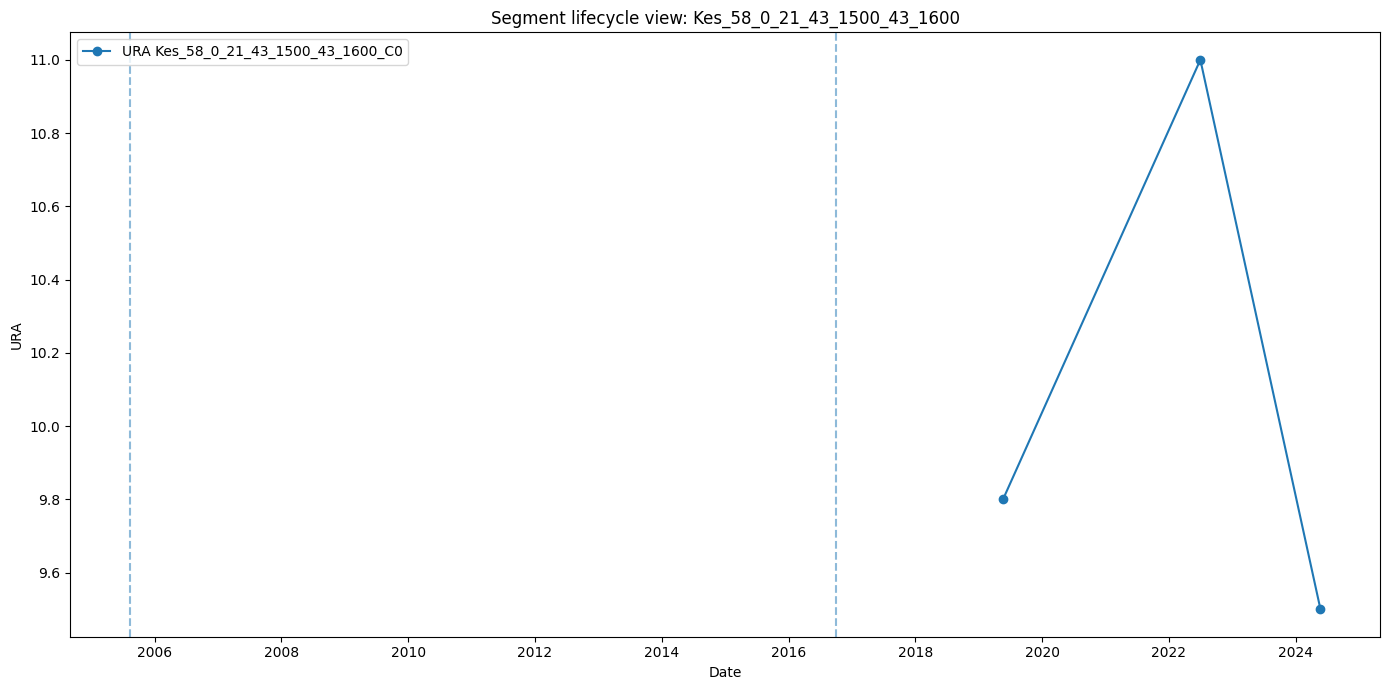

,Segment_ID,Lifecycle_ID,event_date,year,event_type,event_order,Event_Idx,Measurement_Idx,ptm_idx,tp_idx,...,Toim_lk,Pituus,ELY,Tie,Ajorata,Kaista,Aosa,Aet,Losa,Let
0,Kes_58_0_21_43_1500_43_1600,None,2005-08-10,2005,TP,0,1,<NA>,<NA>,2,...,kanta,100,Kes,58,0,21,43,1500,43,1600
1,Kes_58_0_21_43_1500_43_1600,None,2016-09-29,2016,TP,0,2,<NA>,<NA>,1,...,kanta,100,Kes,58,0,21,43,1500,43,1600
2,Kes_58_0_21_43_1500_43_1600,Kes_58_0_21_43_1500_43_1600_C0,2019-05-21,2019,PTM,1,3,1,3,<NA>,...,kanta,100,Kes,58,0,21,43,1500,43,1600
3,Kes_58_0_21_43_1500_43_1600,Kes_58_0_21_43_1500_43_1600_C0,2022-07-01,2022,PTM,1,4,2,2,<NA>,...,kanta,100,Kes,58,0,21,43,1500,43,1600
4,Kes_58_0_21_43_1500_43_1600,Kes_58_0_21_43_1500_43_1600_C0,2024-05-23,2024,PTM,1,5,3,1,<NA>,...,kanta,100,Kes,58,0,21,43,1500,43,1600


In [26]:
def plot_segment_history_by_lifecycle(df, segment_id=None, min_events=5, min_ptm=3, figsize=(14, 7)):
    if segment_id is None:
        segment_id = get_random_segment_id(df, min_events=min_events, min_ptm=min_ptm)

    seg = get_segment_history(df, segment_id)
    ptm_seg = seg[seg["event_type"] == "PTM"].copy()
    tp_seg = seg[seg["event_type"] == "TP"].copy()

    fig, ax = plt.subplots(figsize=figsize)

    if "Lifecycle_ID" in ptm_seg.columns and ptm_seg["Lifecycle_ID"].notna().any():
        for lifecycle_id, g in ptm_seg.groupby("Lifecycle_ID", dropna=False):
            label = f"URA {lifecycle_id}" if pd.notna(lifecycle_id) else "URA (no lifecycle)"
            if "URA" in g.columns:
                ax.plot(g["event_date"], g["URA"], marker="o", label=label)
    else:
        if "URA" in ptm_seg.columns:
            ax.plot(ptm_seg["event_date"], ptm_seg["URA"], marker="o", label="URA")

    if not tp_seg.empty:
        for _, row in tp_seg.iterrows():
            ax.axvline(row["event_date"], linestyle="--", alpha=0.5)

    ax.set_title(f"Segment lifecycle view: {segment_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("URA")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    return seg

seg2 = plot_segment_history_by_lifecycle(df, segment_id=None)
display(seg2)

### Compact text summary for one segment

In [27]:
def summarize_segment(df, segment_id=None, min_events=5, min_ptm=3):
    if segment_id is None:
        segment_id = get_random_segment_id(df, min_events=min_events, min_ptm=min_ptm)

    seg = get_segment_history(df, segment_id)
    ptm_seg = seg[seg["event_type"] == "PTM"].copy()
    tp_seg = seg[seg["event_type"] == "TP"].copy()

    print("Segment_ID:", segment_id)
    print("Total events:", len(seg))
    print("PTM events:", len(ptm_seg))
    print("TP events:", len(tp_seg))

    if "event_date" in seg.columns:
        print("Date range:", seg["event_date"].min(), "->", seg["event_date"].max())

    if "Lifecycle_ID" in seg.columns:
        print("Lifecycles:", seg["Lifecycle_ID"].nunique(dropna=True))

    if "URA" in ptm_seg.columns:
        print("URA range:", ptm_seg["URA"].min(), "->", ptm_seg["URA"].max())

    if "IRI" in ptm_seg.columns:
        print("IRI range:", ptm_seg["IRI"].min(), "->", ptm_seg["IRI"].max())

    if "Tp_pinta" in tp_seg.columns:
        print("\nTop Tp_pinta:")
        display(tp_seg["Tp_pinta"].value_counts(dropna=False).head(10))

    if "Tp_tyomen" in tp_seg.columns:
        print("\nTop Tp_tyomen:")
        display(tp_seg["Tp_tyomen"].value_counts(dropna=False).head(10))

    return seg

seg3 = summarize_segment(df, segment_id=None)

Segment_ID: Pir_325_0_11_6_400_6_500
Total events: 10
PTM events: 8
TP events: 2
Date range: 2007-09-25 00:00:00 -> 2023-06-26 00:00:00
Lifecycles: 2
URA range: 3.3 -> 8.0
IRI range: 0.96 -> 1.79

Top Tp_pinta:


Tp_pinta
PAB-B    1
AB       1
Name: count, dtype: int64


Top Tp_tyomen:


Tp_tyomen
MP    2
Name: count, dtype: int64

### Find interesting segments automatically

In [28]:
segment_summary = build_segment_summary(df)

print("Segments with most events:")
display(segment_summary.head(10))

if "n_tp" in segment_summary.columns:
    print("\nSegments with most TP events:")
    display(segment_summary.sort_values("n_tp", ascending=False).head(10))

if "n_lifecycles" in segment_summary.columns:
    print("\nSegments with most lifecycles:")
    display(segment_summary.sort_values("n_lifecycles", ascending=False).head(10))

KeyboardInterrupt: 

### PTM target-horizon helper preview

In [ ]:
def make_ptm_horizon_preview(df, horizon=1):
    ptm = (
        df[df["event_type"] == "PTM"]
        .sort_values(["Segment_ID", "event_date", "ptm_idx"], kind="mergesort")
        .copy()
    )

    for target_col in ["URA", "IRI", "event_date"]:
        if target_col in ptm.columns:
            ptm[f"{target_col}_t_plus_{horizon}"] = ptm.groupby("Segment_ID")[target_col].shift(-horizon)

    return ptm

preview = make_ptm_horizon_preview(df, horizon=1)
display(preview.head(20))

### Optional: one function to run a compact full audit

In [ ]:
def full_dataset_audit(df):
    print("=== BASIC ===")
    print("Shape:", df.shape)
    print("Unique segments:", df["Segment_ID"].nunique() if "Segment_ID" in df.columns else "NA")
    print("Unique lifecycles:", df["Lifecycle_ID"].nunique(dropna=True) if "Lifecycle_ID" in df.columns else "NA")

    if "event_type" in df.columns:
        print("\n=== EVENT TYPES ===")
        display(df["event_type"].value_counts(dropna=False))

    print("\n=== MISSING VALUES ===")
    display(
        pd.DataFrame({
            "missing_count": df.isna().sum(),
            "missing_pct": df.isna().mean() * 100,
            "dtype": df.dtypes.astype(str),
        }).sort_values("missing_pct", ascending=False).head(30)
    )

    print("\n=== NUMERIC SUMMARY ===")
    num_cols = df.select_dtypes(include=[np.number, "Float64", "Int64"]).columns.tolist()
    display(df[num_cols].describe().T)

    print("\n=== INTEGRITY CHECKS ===")
    checks = {}
    if "event_type" in df.columns:
        checks["invalid event_type"] = (~df["event_type"].isin(["PTM", "TP"])).sum()
    if "event_order" in df.columns:
        checks["invalid event_order"] = (~df["event_order"].isin([0, 1])).sum()
    display(pd.Series(checks, name="count"))

full_dataset_audit(df)

# Faster plotting

In [ ]:
# Run once after loading df

plot_df = df.sort_values(
    ["Segment_ID", "event_date", "event_order", "ptm_idx", "tp_idx"],
    kind="mergesort",
    na_position="last"
).reset_index(drop=True)

# Fast row-range lookup for each segment
segment_bounds = (
    plot_df.groupby("Segment_ID", sort=False)
    .apply(lambda g: pd.Series({"start": g.index[0], "end": g.index[-1] + 1}))
)

# Optional: precompute summary for random selection
segment_stats = (
    plot_df.groupby("Segment_ID")
    .agg(
        n_events=("Segment_ID", "size"),
        n_ptm=("event_type", lambda s: (s == "PTM").sum()),
        n_tp=("event_type", lambda s: (s == "TP").sum()),
    )
)

print("Prepared fast plotting index.")
print("Segments:", len(segment_bounds))

C:\Users\mkjun\AppData\Local\Temp\ipykernel_11920\646897493.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({"start": g.index[0], "end": g.index[-1] + 1}))


Prepared fast plotting index.
Segments: 1064380


In [ ]:
def get_segment_history_fast(segment_id, plot_df=plot_df, segment_bounds=segment_bounds):
    if segment_id not in segment_bounds.index:
        raise ValueError(f"Segment_ID not found: {segment_id}")

    row = segment_bounds.loc[segment_id]
    return plot_df.iloc[int(row["start"]):int(row["end"])].copy()

def get_random_segment_id_fast(min_events=5, min_ptm=3, segment_stats=segment_stats):
    eligible = segment_stats[
        (segment_stats["n_events"] >= min_events) &
        (segment_stats["n_ptm"] >= min_ptm)
    ].index

    if len(eligible) == 0:
        raise ValueError("No eligible segments found.")

    return np.random.choice(eligible)

def plot_segment_history_fast(
    segment_id=None,
    min_events=5,
    min_ptm=3,
    figsize=(14, 7),
    show_tp_labels=True,
    max_tp_labels=20,
    return_segment=True,
):
    if segment_id is None:
        segment_id = get_random_segment_id_fast(min_events=min_events, min_ptm=min_ptm)

    seg = get_segment_history_fast(segment_id)
    ptm_seg = seg[seg["event_type"] == "PTM"]
    tp_seg = seg[seg["event_type"] == "TP"]

    fig, ax = plt.subplots(figsize=figsize)

    if not ptm_seg.empty and "URA" in ptm_seg.columns:
        ax.plot(ptm_seg["event_date"], ptm_seg["URA"], marker="o", label="URA")

    if not ptm_seg.empty and "IRI" in ptm_seg.columns:
        ax.plot(ptm_seg["event_date"], ptm_seg["IRI"], marker="s", label="IRI")

    if not tp_seg.empty:
        tp_dates = pd.to_datetime(tp_seg["event_date"]).to_numpy()
        for d in tp_dates:
            ax.axvline(d, linestyle="--", alpha=0.4)

        if show_tp_labels:
            ymin, ymax = ax.get_ylim()

            # label only up to max_tp_labels events to keep plot usable
            label_tp = tp_seg.head(max_tp_labels)

            labels = (
                label_tp[["Tp_pinta", "Tp_tyomen"]]
                .fillna("")
                .astype(str)
                .agg(lambda x: " | ".join([v for v in x if v.strip()]), axis=1)
            )

            for d, txt in zip(label_tp["event_date"], labels):
                if txt:
                    ax.text(
                        d, ymax, txt,
                        rotation=90,
                        va="top",
                        ha="right",
                        fontsize=8
                    )

    ax.set_title(f"Segment history: {segment_id}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Condition value")
    ax.legend()
    plt.tight_layout()
    plt.show()

    if return_segment:
        return seg

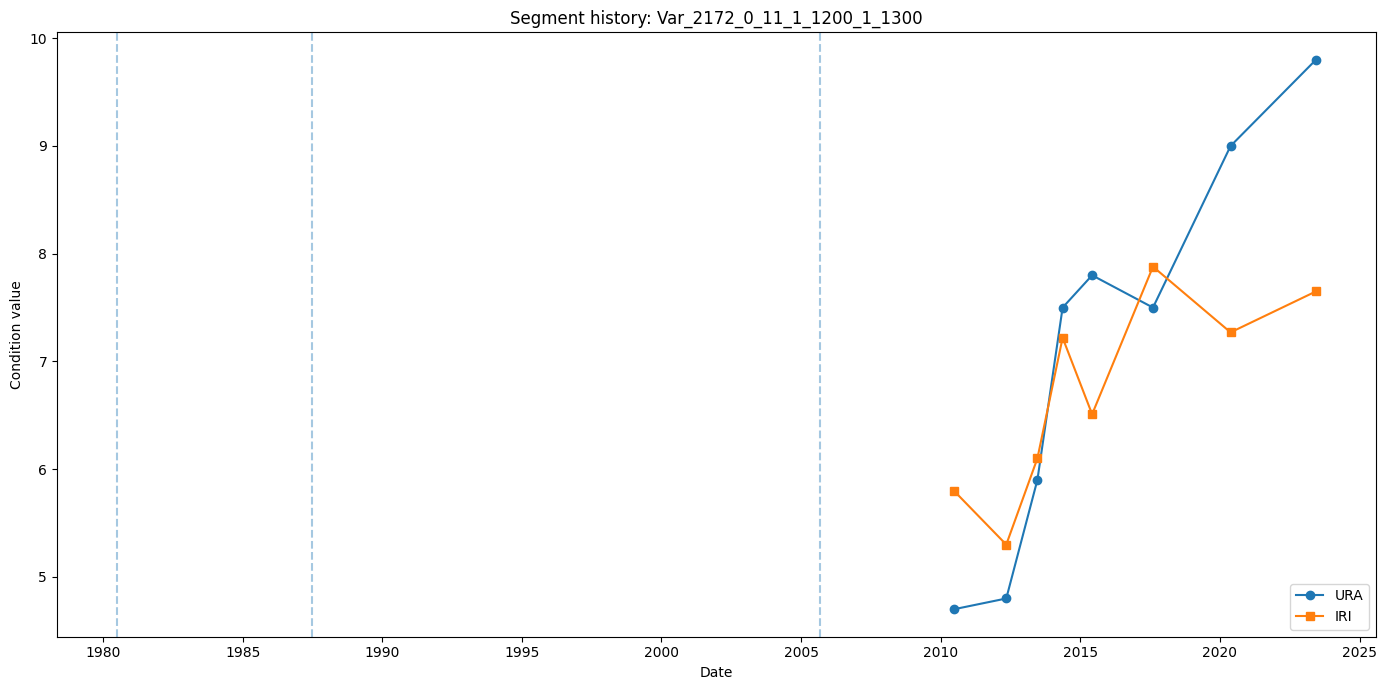

,Segment_ID,Lifecycle_ID,event_date,year,event_type,event_order,Event_Idx,Measurement_Idx,ptm_idx,tp_idx,...,Toim_lk,Pituus,ELY,Tie,Ajorata,Kaista,Aosa,Aet,Losa,Let
8645121,Var_2172_0_11_1_1200_1_1300,None,1980-06-30,1980,TP,0,1,<NA>,NaN,3.0,...,yhdys,100,Var,2172,0,11,1,1200,1,1300
8645122,Var_2172_0_11_1_1200_1_1300,None,1987-06-30,1987,TP,0,2,<NA>,NaN,2.0,...,yhdys,100,Var,2172,0,11,1,1200,1,1300
8645123,Var_2172_0_11_1_1200_1_1300,None,2005-09-01,2005,TP,0,3,<NA>,NaN,1.0,...,yhdys,100,Var,2172,0,11,1,1200,1,1300
8645124,Var_2172_0_11_1_1200_1_1300,Var_2172_0_11_1_1200_1_1300_C0,2010-06-22,2010,PTM,1,4,1,8.0,NaN,...,yhdys,100,Var,2172,0,11,1,1200,1,1300
8645125,Var_2172_0_11_1_1200_1_1300,Var_2172_0_11_1_1200_1_1300_C0,2012-05-07,2012,PTM,1,5,2,7.0,NaN,...,yhdys,100,Var,2172,0,11,1,1200,1,1300
8645126,Var_2172_0_11_1_1200_1_1300,Var_2172_0_11_1_1200_1_1300_C0,2013-06-18,2013,PTM,1,6,3,6.0,NaN,...,yhdys,100,Var,2172,0,11,1,1200,1,1300
8645127,Var_2172_0_11_1_1200_1_1300,Var_2172_0_11_1_1200_1_1300_C0,2014-05-14,2014,PTM,1,7,4,5.0,NaN,...,yhdys,100,Var,2172,0,11,1,1200,1,1300
8645128,Var_2172_0_11_1_1200_1_1300,Var_2172_0_11_1_1200_1_1300_C0,2015-06-04,2015,PTM,1,8,5,4.0,NaN,...,yhdys,100,Var,2172,0,11,1,1200,1,1300
8645129,Var_2172_0_11_1_1200_1_1300,Var_2172_0_11_1_1200_1_1300_C0,2017-08-08,2017,PTM,1,9,6,3.0,NaN,...,yhdys,100,Var,2172,0,11,1,1200,1,1300
8645130,Var_2172_0_11_1_1200_1_1300,Var_2172_0_11_1_1200_1_1300_C0,2020-05-19,2020,PTM,1,10,7,2.0,NaN,...,yhdys,100,Var,2172,0,11,1,1200,1,1300


In [ ]:
seg = plot_segment_history_fast(segment_id=None, show_tp_labels=False)
seg.head(20)